In [ ]:
import pandas as pd
import re
import datetime
import seaborn as sns
import matplotlib.pyplot as plt
import json

In [ ]:
pd.set_option('display.max_colwidth', None)

In [ ]:
def clean_text(input_text):
    # Удаляем смайлики
    cleaned_text = re.sub(r'[\U0001F600-\U0001F64F\U0001F300-\U0001F5FF\U0001F680-\U0001F6FF\U0001F700-\U0001F77F\U0001F780-\U0001F7FF\U0001F800-\U0001F8FF\U0001F900-\U0001F9FF\U0001FA00-\U0001FA6F\U0001FA70-\U0001FAFF\U00002702-\U000027B0\U000024C2-\U0001F251]+', '', input_text)
    # Удаляем знаки препинания и другие символы
    cleaned_text = re.sub(r'[^\w\s]', '', cleaned_text)
    return cleaned_text.replace('n', ' ')

# предобработка новостных данных

In [ ]:
df = pd.read_csv('tviks_data.csv')

In [ ]:
df['text'] = df['text'].map(lambda x: clean_text(x))
df['text'].head()

0                                                                                                                                                                                                                                                                                                                Видео дня толстенького тойтерьера Арчи вернули хозяину Пса искали 10 дней \n\nПитомец оказался без хозяина в электричке и его высадили К счастью  Арчи повезло больше чем коту Твиксу
1                                                                                                                                                                                                                      РЖД внесут изменения в документы по перевозке животных в поездах проводникам запретят их высаживать\n\nПоводом стал случай когда проводница РЖД посчитала бродившего по вагону кота бездомным и выкинула его на улицу Кота Твикса искали около недели сегодня его нашли мертвым
2                         

In [ ]:
df.columns

Index(['id', 'channel_id', 'channel', 'date', 'text', 'views', 'id_owner',
       'url', 'avatar', 'text_length', 'reposts_count', 'comments_count',
       'comments', 'reactions', 'tg_channel_id'],
      dtype='object')

In [ ]:
datetime.datetime.utcfromtimestamp(1706272976)#.strftime('%Y-%m-%dT%H:%M:%SZ')

datetime.datetime(2024, 1, 26, 12, 42, 56)

In [ ]:
data = df.loc[:, ['text', 'date']]
data

,text,date
0,Видео дня толстенького тойтерьера Арчи вернули хозяину Пса искали 10 дней \n\nПитомец оказался без хозяина в электричке и его высадили К счастью Арчи повезло больше чем коту Твиксу,1706272976
1,РЖД внесут изменения в документы по перевозке животных в поездах проводникам запретят их высаживать\n\nПоводом стал случай когда проводница РЖД посчитала бродившего по вагону кота бездомным и выкинула его на улицу Кота Твикса искали около недели сегодня его нашли мертвым,1705748566
2,Против проводницы выбросившей кота Твикса из поезда в Кирове завели уголовное дело\n\nСправедливо,1706124333
3,В РЖД запретят высаживать животных из поездов дальнего следования после трагедии с котом Твиксом \n\nВо время поездки кот убежал из переноски и проводница выбросила его из поезда который направлялся в СанктПетербург Позже его нашли мертвым у железнодорожного переезда \n\nВ компании уже готовят изменения в нормативные документы Теперь в подобных ситуациях животных будут передавать работникам на остановочных пунктах а впоследствии вызывать представителей зоозащитных организаций,1705747623
4,166 тысяч россиян подписали петицию с требованием уволить проводницу выкинувшую из поезда кота Твикса что привело к его гибели,1705773256
...,...,...
115,Против проводницы которая выбросила кота Твикса из поезда завели уголовное дело РИА Новости \n\nАгентство сообщает об этом со ссылкой на источник знакомый с ситуацией По какой статье возбуждено дело собеседник РИА Новости не уточнил Телеканал RT со ссылкой на источник в правоохранительных органах утверждает что дело завели по статье о жестоком обращении с животными\n\n22 января глава Следственного комитета России Александр Бастрыкин поручил проести проверку по факту жестокого обращения с животным после гибели кота Твикса На следующий день в РЖД отчитались что проводницу временно отстранили от работы с пассажирами\n\n\n\nОбновлено 25 января ТАСС сообщил что следствие все еще проводит проверку а уголовное дело не возбуждено Имеется ли в виду дело против проводницы из публикации агентства неясно,1706132521
116,Уголовное дело после смерти кота Твикса не возбуждено пишет ТАСС\n\nАгентство уточняет что следствие все еще проводит проверку Кого и на что проверяют не сообщают\n\nОб уголовном деле против проводницы поезда сообщили вчера в РИА Новости В RT уточнили что его возбудили по статье о жестоком обращении с животными О возбужденном уголовном деле вчера также написали и в ТАСС ссылаясь на публикацию в телеграмканале Твикс Информация от хозяина\n\n22 января провести проверку поручил глава Следственного комитета Александр Бастрыкин,1706171619
117,Уголовное дело после гибели кота Твикса всетаки возбудили но не в отношении конкретного лица Новая газета\n\nДело открыли по статье о жестоком обращении с животными пишет издание со ссылкой на юриста Сергей Егоров который представляет хозяев погибшего животного \n\nСообщается что Егоров и его доверители ознакомились с постановлением о возбуждении уголовного дела Документ также есть в распоряжении редакции Новой газеты\n\nПреступление небольшой тяжести и если ранее лицо не привлекалось к ответственности за такого рода преступления практика показывает что в наказание назначают в виде штрафа а не тюремного срока цитирует редакция адвоката\n\n\n\n24 января РИА Новости и RT заявили что дело возбудили против проводницы поезда на котором везли животное Источник ТАСС заявил что дело не возбуждали,1706188282
118,25 января стало известно что Следственный комитет возбудил уголовное дело о жестоком обращении с животными изза смерти кота Твикса Кот погиб после того как проводница поезда Екатеринбург СанктПетербург выпустила его на станции подумав что животное бездомное и забежало в поезд случайно \n\nНа самом деле Твикса везли к его хозяину в Петербург в том самом поезде Человек который должен был следить за котом заснул и Твикс выбрался из переноски Кота искали сотни волонтеров но он был найден погибшим В уголовном деле изза его гибели пока нет конкретных фигурантов \n\nК сож

In [ ]:
panda_df = pd.read_csv('panda_data.csv')
panda_df['text'] = panda_df['text'].map(lambda x: clean_text(x))
panda = panda_df.loc[:, ['text']]
panda.head()

,text
0,В Московском зоопарке родился первый в истории России детеныш большой панды
1,Детеныш панды родившаяся в Москве открыла глаза на 42й день жизни видео с ней публикует гендиректор столичного зоопарка\n\nМаленькая панда уже реагирует на свет но нормально видеть начнет только к концу октября
2,Детёныш больших панд Жуи и Диндин из Московского зоопарка впервые в жизни прошёл медосмотр в корзинке До этого здоровье пандочки всегда проверяли в специальном инкубаторе\n\nМалышка весит почти три килограмма Какихлибо проблем со здоровьем у крохи не обнаружено После осмотра панду сразу же вернули к любимой маме Специалисты говорят что в первое время очень важно надолго их не разлучать
3,Отвлекитесь от политических новостей и посмотрите как в Московском зоопарке полный чекап проходит панда Жуи
4,Минутка доброты у детеныша панды в Московском зоопарке прорезались первые зубки


# предобработка комментов

In [ ]:
def get_comments(comment_series):
  comments = []
  for row in comment_series:
    if row != "[]":
      for json_str in row.split('{')[1:]:
        find_comment = json_str.find('\'text\':')
        comment = json_str[find_comment + len('\'text\': ') + 1:-3]
        comment = comment[:-1] if comment[-1] == "'" else comment
        #print(comment)
        comments.append(comment)
        #print(clean_text(comment))
  return comments

In [ ]:
twix_comments = get_comments(df['comments'])

In [ ]:
cleaned_twix_comments = [clean_text(comment) for comment in twix_comments]
while "" in cleaned_twix_comments:
  cleaned_twix_comments.remove('')

In [ ]:
panda_comments = get_comments(panda_df['comments'])

cleaned_panda_comments = [clean_text(comment) for comment in panda_comments]
while "" in cleaned_panda_comments:
  cleaned_panda_comments.remove('')

# Dostoevsky

библиотека по какой-то причине отвалилась и показывает одинаковый скор окраски для любых текстов :/

In [ ]:
pip install dostoevsky

In [ ]:
!python -m dostoevsky download fasttext-social-network-model

In [ ]:
from dostoevsky.tokenization import RegexTokenizer
from dostoevsky.models import FastTextSocialNetworkModel

tokenizer = RegexTokenizer()
model = FastTextSocialNetworkModel(tokenizer=tokenizer)

In [ ]:
post = list(data['text'])

In [ ]:
res = model.predict(post, k=1)

In [ ]:
sentiment_verdict = [list(el.keys())[0] for el in res]
sentiment_score = [list(el.values())[0] for el in res]

In [ ]:
dostoevsky_rez = pd.DataFrame(data['text'])
dostoevsky_rez.loc[:, 'sentiment verdict'] = sentiment_verdict
dostoevsky_rez.loc[:, 'sentiment score'] = sentiment_score
dostoevsky_rez.drop(dostoevsky_rez[dostoevsky_rez['sentiment verdict'] == 'skip'].index, inplace = True)

dostoevsky_rez.head()

,text,sentiment verdict,sentiment score
1,"РЖД внесут изменения в документы по перевозке животных в поездах, проводникам запретят их высаживать Поводом стал случай, когда проводница РЖД посчитала бродившего по вагону кота бездомным и выкинула его на улицу. Кота Твикса искали около недели, сегодня его нашли мертвым.",neutral,0.407343
2,"‍ Против проводницы, выбросившей кота Твикса из поезда в Кирове, завели уголовное дело Справедливо?",neutral,0.562187
3,"В РЖД запретят высаживать животных из поездов дальнего следования после трагедии с котом Твиксом. Во время поездки кот убежал из переноски и проводница выбросила его из поезда, который направлялся в Санкт-Петербург. Позже его нашли мертвым у железнодорожного переезда. В компании уже готовят изменения в нормативные документы. Теперь в подобных ситуациях животных будут передавать работникам на остановочных пунктах, а впоследствии вызывать представителей зоозащитных организаций.",neutral,0.724880
4,"166 тысяч россиян подписали петицию с требованием уволить проводницу, выкинувшую из поезда кота Твикса, что привело к его гибели.",neutral,0.607673
5,"Проводник, высадившая кота Твикса, временно отстранена от работы — замгендиректора РЖД",neutral,0.392347


In [ ]:
panda_res = model.predict(panda['text'].tolist(), k=1)

dostoevsky_panda = pd.DataFrame(panda['text'])
dostoevsky_panda.loc[:, 'sentiment'] = [list(el.keys())[0] for el in panda_res]
dostoevsky_panda.loc[:, 'sentiment score'] = [list(el.values())[0] for el in panda_res]
dostoevsky_panda.drop(dostoevsky_panda[dostoevsky_panda['sentiment'] == 'speech'].index, inplace = True)
dostoevsky_panda.drop(dostoevsky_panda[dostoevsky_panda['sentiment'] == 'skip'].index, inplace = True)

dostoevsky_panda.head()


,text,sentiment,sentiment score
0,В Московском зоопарке родился первый в истории России детеныш большой панды,neutral,0.600198
1,"Детеныш панды, родившаяся в Москве, открыла глаза на 42-й день жизни, видео с ней публикует гендиректор столичного зоопарка. Маленькая панда уже реагирует на свет, но нормально видеть начнет только к концу октября.",neutral,0.569863
2,"Детёныш больших панд Жуи и Диндин из Московского зоопарка впервые в жизни прошёл медосмотр в корзинке. До этого здоровье пандочки всегда проверяли в специальном инкубаторе. Малышка весит почти три килограмма. Каких-либо проблем со здоровьем у крохи не обнаружено. После осмотра панду сразу же вернули к любимой маме. Специалисты говорят, что в первое время очень важно надолго их не разлучать.",neutral,0.275140
3,"Отвлекитесь от политических новостей и посмотрите, как в Московском зоопарке полный чек-ап проходит панда Жуи",neutral,0.749097
5,Минутка доброты: осмотр детеныша панды в Московском зоопарке,neutral,0.422515


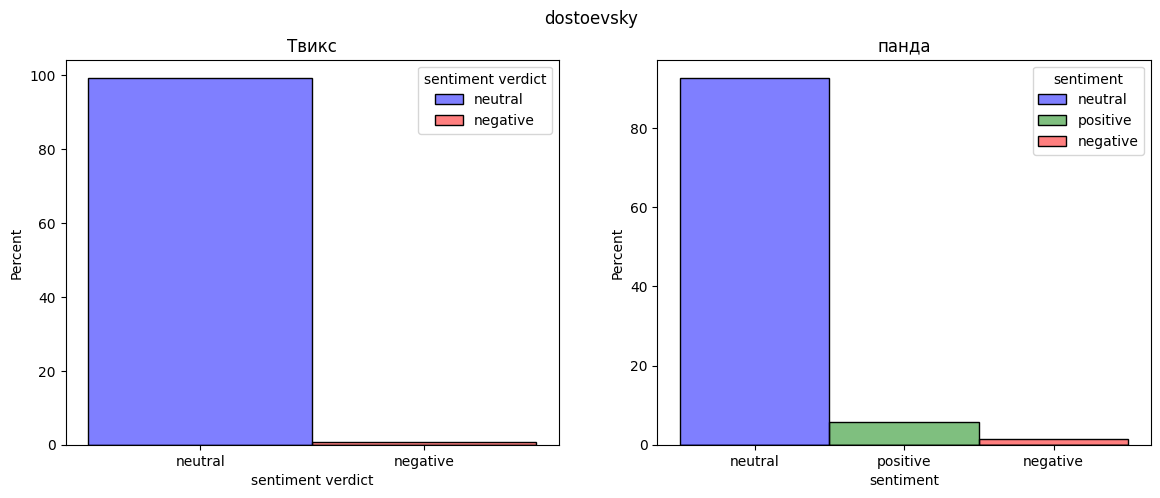

In [ ]:
plt.figure(figsize=(14,5))

plt.subplot(1,2,1)
sns.histplot(data=dostoevsky_rez, x='sentiment verdict', stat='percent', hue='sentiment verdict', palette=['blue', 'red'])
plt.title('Твикс')

plt.subplot(1, 2, 2)
sns.histplot(data=dostoevsky_panda, x='sentiment', stat='percent', hue='sentiment', palette=['blue', 'green', 'red'])
plt.title('панда')

plt.suptitle('dostoevsky')

plt.show()

In [ ]:
dostoevsky_rez[dostoevsky_rez['sentiment verdict'] == 'negative']['text']

36    Кот Твикс стал огромной историей, потому что этот протест против проводницы и РЖД в защиту мёртвого кота, – просто сублимация протестных настроений. Они остались, но в условиях СВО люди опасаются их высказать. И то, что они говорят про проводницу и РЖД, они на самом деле хотели бы сказать про власть. Но боятся. Сергей Марков
Name: text, dtype: object

# Bert'ы

In [ ]:
!pip3 install transformers

In [ ]:
import torch
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

##seara/rubert-tiny2-russian-sentiment

In [ ]:
from transformers import pipeline

seara_pipe = pipeline("text-classification", model="seara/rubert-tiny2-russian-sentiment", device=device)

/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_token.py:88: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/911 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/117M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/368 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/1.08M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.41M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

In [ ]:
results = seara_pipe(data['text'].tolist(), batch_size=8)

res_panda = seara_pipe(panda['text'].tolist(), batch_size=16)

In [ ]:
seara_rubert = data.assign(sentiment=[result['label'] for result in results],
                           score=[result['score'] for result in results])

seara_rubert_panda = panda.assign(sentiment=[result['label'] for result in res_panda],
                           score=[result['score'] for result in res_panda])

In [ ]:
seara_rubert.head()

,text,date,sentiment,score
0,"Видео дня: толстенького той-терьера Арчи вернули хозяину. Пса искали 10 дней. Питомец оказался без хозяина в электричке и его высадили. К счастью — Арчи повезло больше, чем коту Твиксу",1706272976,neutral,0.731687
1,"РЖД внесут изменения в документы по перевозке животных в поездах, проводникам запретят их высаживать Поводом стал случай, когда проводница РЖД посчитала бродившего по вагону кота бездомным и выкинула его на улицу. Кота Твикса искали около недели, сегодня его нашли мертвым.",1705748566,negative,0.584642
2,"‍ Против проводницы, выбросившей кота Твикса из поезда в Кирове, завели уголовное дело Справедливо?",1706124333,negative,0.621349
3,"В РЖД запретят высаживать животных из поездов дальнего следования после трагедии с котом Твиксом. Во время поездки кот убежал из переноски и проводница выбросила его из поезда, который направлялся в Санкт-Петербург. Позже его нашли мертвым у железнодорожного переезда. В компании уже готовят изменения в нормативные документы. Теперь в подобных ситуациях животных будут передавать работникам на остановочных пунктах, а впоследствии вызывать представителей зоозащитных организаций.",1705747623,negative,0.534769
4,"166 тысяч россиян подписали петицию с требованием уволить проводницу, выкинувшую из поезда кота Твикса, что привело к его гибели.",1705773256,negative,0.861582


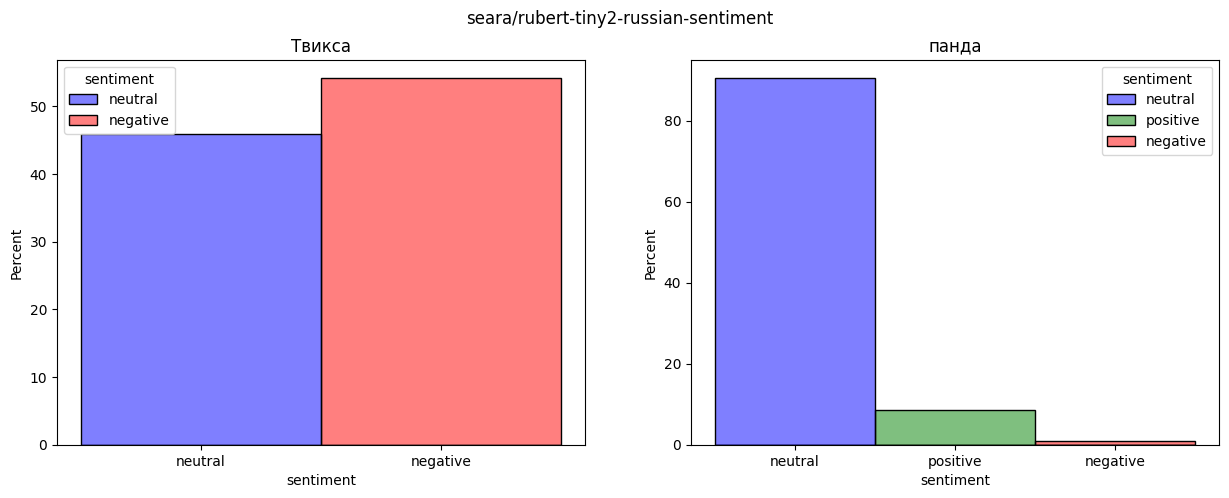

In [ ]:
plt.figure(figsize=(15,5))

plt.subplot(1,2,1)
sns.histplot(data=seara_rubert, x='sentiment', stat='percent', hue='sentiment', palette=['blue', 'red'])
plt.title('Твикса')

plt.subplot(1, 2, 2)
sns.histplot(data=seara_rubert_panda, x='sentiment', stat='percent', hue='sentiment', palette=['blue', 'green', 'red'])
plt.title('панда')

plt.suptitle('seara/rubert-tiny2-russian-sentiment')

plt.show()

In [ ]:
seara_rubert[seara_rubert['sentiment'] == 'negative']['score'].argmax()

41

In [ ]:
seara_rubert.iloc[41]['text']

'Народный художник РФ Никас Сафронов решил увековечить кота Твикса на холсте своей картины.'

In [ ]:
print(seara_rubert.iloc[seara_rubert[seara_rubert['sentiment'] == 'negative']['score'].argmin()]['text'])#.replace(r'\x', ' ')

Депутат Госдумы, первый зампред фракции «Справедливая Россия» Дмитрий Гусев о ситуации с котором Твиксом специально для BRIEF: Крайней, конечно, оказалась проводница. Хотела как лучше — получилось так, как получилось. Но мы сейчас, требуя наказания для нее, ничего не добьемся. Надо успокоиться. Она уже триста раз себя прокляла и прокляла свои действия. Я думаю, что она уже не знает, что делать, и я уверен, что ей за свой поступок стыдно. Это — самое главное для нее наказание, как она с этим потом будет жить. А нам сейчас надо не уподобляться этой проводнице, не применять к ней карательные действия, тем более, что правоохранительные органы уже провели проверку и не усмотрели в ее действиях уголовного состава.


In [ ]:
rubert_comments = seara_pipe(cleaned_twix_comments, batch_size=8)

In [ ]:
seara_rubert_com_twix = pd.DataFrame({'comment' : cleaned_twix_comments, 'sentiment' : [result['label'] for result in rubert_comments], 'sentiment score' : [result['score'] for result in rubert_comments]})
seara_rubert_com_twix.head()

,comment,sentiment,sentiment score
0,Правильно Только вот проводницу уволить или оштрафовать серьезно нужно Если до ГосДумы дойдет или до Путина то вполне могут быть такие решения по Конституции и поправкам о защите животных,neutral,0.831991
1,Вот тварь,negative,0.515460
2,А то есть раньше могли спокойно выкидывать и всё,neutral,0.753649
3,Правильно Логично Котика жаль,neutral,0.625922
4,Безумно жаль котика,negative,0.532785


In [ ]:
seara_rubert_com_twix[seara_rubert_com_twix['sentiment'] == 'positive']

,comment,sentiment,sentiment score
36,Подписал,positive,0.579084
60,кота конечно жалко но это реально клоунада ахахахха,positive,0.788450
67,ура твикс популярный,positive,0.975141
151,ваще похуй,positive,0.460010
163,Спасибо за твою жертву Твикс Благодаря тебе больше не будет таких жертв,positive,0.614713
169,Согл,positive,0.466612
176,Ура,positive,0.989051
178,Все правильно,positive,0.776754
186,молодцы,positive,0.990418
187,это очень вкусное мороженое,positive,0.986219


In [ ]:
rubert_comments_panda = seara_pipe(cleaned_panda_comments, batch_size=8)

seara_rubert_com_panda = pd.DataFrame({'sentiment' : [result['label'] for result in rubert_comments_panda], 'sentiment score' : [result['score'] for result in rubert_comments_panda]})
seara_rubert_com_panda.head()

,sentiment,sentiment score
0,neutral,0.797740
1,neutral,0.626817
2,neutral,0.438575
3,positive,0.994513
4,positive,0.928012


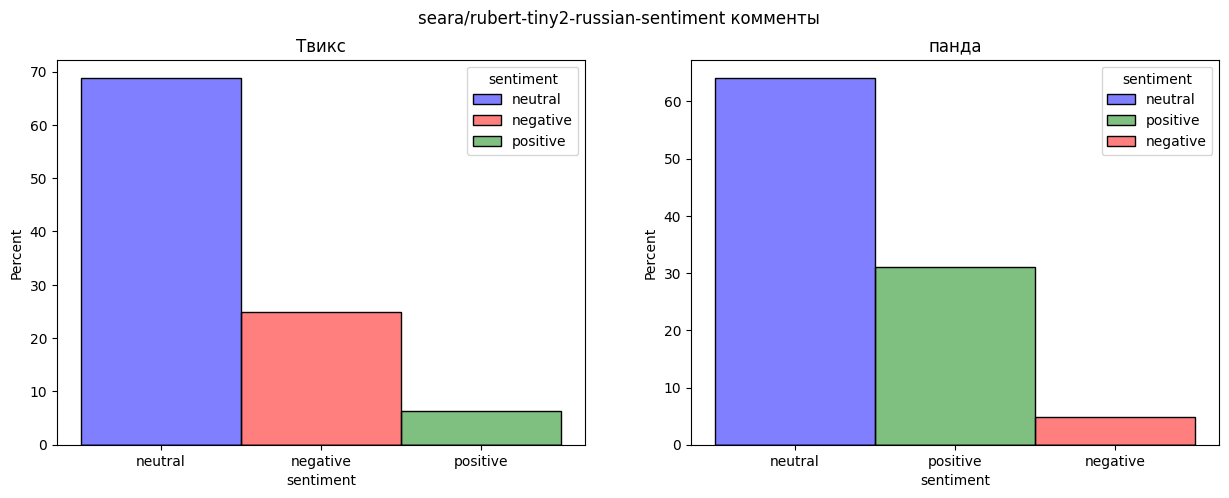

In [ ]:
plt.figure(figsize=(15,5))

plt.subplot(1,2,1)
sns.histplot(data=seara_rubert_com_twix, x='sentiment', stat='percent', hue='sentiment', palette=['blue', 'red', 'green'])
plt.title('Твикс')

plt.subplot(1, 2, 2)
sns.histplot(data=seara_rubert_com_panda, x='sentiment', stat='percent', hue='sentiment', palette=['blue', 'green', 'red'])
plt.title('панда')

plt.suptitle('seara/rubert-tiny2-russian-sentiment комменты')

plt.show()

## lxyuan/distilbert-base-multilingual-cased-sentiments-student

In [ ]:
distilbert_pipe = pipeline("text-classification", model="lxyuan/distilbert-base-multilingual-cased-sentiments-student", device=device)

config.json:   0%|          | 0.00/759 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/541M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/373 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/996k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.92M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

In [ ]:
results = distilbert_pipe(data['text'].tolist(), batch_size=16, truncation=True)

distilbert = data.assign(sentiment=[result['label'] for result in results],
                           score=[result['score'] for result in results])

In [ ]:
distilbert.head()

,text,date,sentiment,score
0,"Видео дня: толстенького той-терьера Арчи вернули хозяину. Пса искали 10 дней. Питомец оказался без хозяина в электричке и его высадили. К счастью — Арчи повезло больше, чем коту Твиксу",1706272976,negative,0.612381
1,"РЖД внесут изменения в документы по перевозке животных в поездах, проводникам запретят их высаживать Поводом стал случай, когда проводница РЖД посчитала бродившего по вагону кота бездомным и выкинула его на улицу. Кота Твикса искали около недели, сегодня его нашли мертвым.",1705748566,negative,0.757302
2,"‍ Против проводницы, выбросившей кота Твикса из поезда в Кирове, завели уголовное дело Справедливо?",1706124333,negative,0.764991
3,"В РЖД запретят высаживать животных из поездов дальнего следования после трагедии с котом Твиксом. Во время поездки кот убежал из переноски и проводница выбросила его из поезда, который направлялся в Санкт-Петербург. Позже его нашли мертвым у железнодорожного переезда. В компании уже готовят изменения в нормативные документы. Теперь в подобных ситуациях животных будут передавать работникам на остановочных пунктах, а впоследствии вызывать представителей зоозащитных организаций.",1705747623,negative,0.574691
4,"166 тысяч россиян подписали петицию с требованием уволить проводницу, выкинувшую из поезда кота Твикса, что привело к его гибели.",1705773256,negative,0.808618


In [ ]:
panda_results = distilbert_pipe(panda['text'].tolist(), batch_size=16, truncation=True)

distilbert_panda = panda.assign(sentiment=[result['label'] for result in panda_results],
                           score=[result['score'] for result in panda_results])

In [ ]:
distilbert_panda.head()

,text,sentiment,score
0,В Московском зоопарке родился первый в истории России детеныш большой панды,negative,0.487806
1,"Детеныш панды, родившаяся в Москве, открыла глаза на 42-й день жизни, видео с ней публикует гендиректор столичного зоопарка. Маленькая панда уже реагирует на свет, но нормально видеть начнет только к концу октября.",positive,0.417185
2,"Детёныш больших панд Жуи и Диндин из Московского зоопарка впервые в жизни прошёл медосмотр в корзинке. До этого здоровье пандочки всегда проверяли в специальном инкубаторе. Малышка весит почти три килограмма. Каких-либо проблем со здоровьем у крохи не обнаружено. После осмотра панду сразу же вернули к любимой маме. Специалисты говорят, что в первое время очень важно надолго их не разлучать.",negative,0.446493
3,"Отвлекитесь от политических новостей и посмотрите, как в Московском зоопарке полный чек-ап проходит панда Жуи",positive,0.485199
4,Минутка доброты: у детеныша панды в Московском зоопарке прорезались первые зубки,positive,0.833624


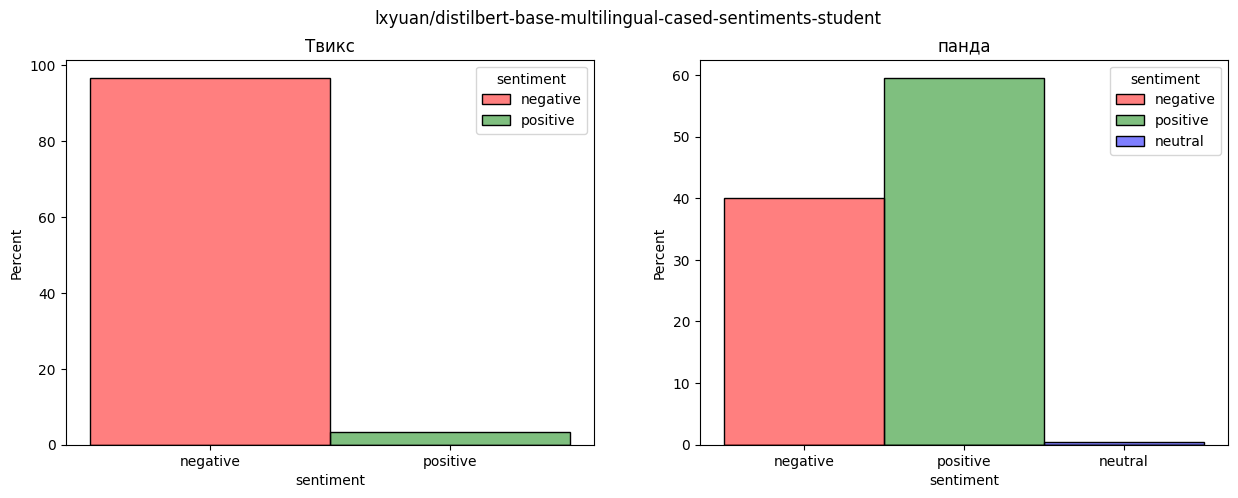

In [ ]:
plt.figure(figsize=(15,5))

plt.subplot(1,2,1)
sns.histplot(data=distilbert, x='sentiment', stat='percent', hue='sentiment', palette=['red', 'green'])
plt.title('Твикс')

plt.subplot(1, 2, 2)
sns.histplot(data=distilbert_panda, x='sentiment', stat='percent', hue='sentiment', palette=['red', 'green', 'blue'])
plt.title('панда')

plt.suptitle('lxyuan/distilbert-base-multilingual-cased-sentiments-student')

plt.show()

In [ ]:
distilbert[distilbert['sentiment'] == 'positive']

,text,date,sentiment,score
27,Екатерина Мизулина предложила установить в Кирове памятник коту Твиксу.,1705761986,positive,0.518111
29,"Говорят, за мёртвого кота Твикса собрано за один день подписей в 5 раз больше, чем за почти месяц за кандидата в президенты Надеждина. Бедный Твикс! Бедный Надеждин! Сергей Марков",1705819741,positive,0.658977
41,Народный художник РФ Никас Сафронов решил увековечить кота Твикса на холсте своей картины.,1706030091,positive,0.601558
107,"Следите за жизнью в столице в видеоформате! Наши друзья из канала Мосфид запустили новостной дайджест с комиком Ильёй Петруком в роли ведущего В первом выпуске: заказное убийство собственного сына, гражданская война в США и продолжение истории с котом Твиксом — всё самое интересное, чем жила Россия и мир на прошедшей неделе. Бежим смотреть новый ролик и подписываемся на каналы, скоро там будет море интересного для москвичей контента: смотреть на YouTube / смотреть в VK",1706631274,positive,0.605324


In [ ]:
distilbert_panda[distilbert_panda['sentiment'] == 'negative']

,text,sentiment,score
0,В Московском зоопарке родился первый в истории России детеныш большой панды,negative,0.487806
2,"Детёныш больших панд Жуи и Диндин из Московского зоопарка впервые в жизни прошёл медосмотр в корзинке. До этого здоровье пандочки всегда проверяли в специальном инкубаторе. Малышка весит почти три килограмма. Каких-либо проблем со здоровьем у крохи не обнаружено. После осмотра панду сразу же вернули к любимой маме. Специалисты говорят, что в первое время очень важно надолго их не разлучать.",negative,0.446493
11,"Российский бамбук не понравился большим пандам Жуи и Диньдинь из Московского зоопарка Бамбук изначально привозили из Китая, но из-за пандемии начали возить из Адлера. Панды не очень оценили его, видимо, он оказался суховатым и недостаточно влажным. Сейчас бамбук возят из Голландии.",negative,0.560312
18,"Московский зоопарк показал, как проходил осмотр маленькой панды",negative,0.419795
19,"Малышка-панда из Московского зоопарка открыла глаза, это произошло на 42-й день ее жизни",negative,0.513535
...,...,...,...
191,"С каждым днем крошка-панда из Московского зоопарка познает все больше эмоций. Как и все мы, она может грустить, радоваться, быть задумчивой и удивленной. Ставьте реакцию, какая панда олицетворяет сегодня вас: — радостная; — грустная; — удивленная; — крайне удивленная; — любопытная; — задумчивая. Уже более 300 тысяч человек проголосовали за лучшее имя для пушистой малышки. До конца голосования осталось совсем немного. Успейте сделать свой выбор. Еще больше милых видео с животными — в телеграм-канале «Город Москва».",negative,0.469839
192,Вот как проводят воскресенье всеми известные панды из Московского зоопарка. А что делаете Вы? Пишите в комментариях,negative,0.498652
195,Вы только посмотрите на милейшие глазки панды из Московского зоопарка.,negative,0.450451
196,Маленькая панда из Московского зоопарка уже уверенно стоит на лапках. Порадуемся за нее в комментариях,negative,0.458881


In [ ]:
distilbert_twix = distilbert_pipe(cleaned_twix_comments, batch_size=16, truncation=True)

distilbert_com_twix = pd.DataFrame({'comment' : cleaned_twix_comments, 'sentiment' : [result['label'] for result in distilbert_twix], 'sentiment score' : [result['score'] for result in distilbert_twix]})
distilbert_com_twix.head()

,comment,sentiment,sentiment score
0,Правильно Только вот проводницу уволить или оштрафовать серьезно нужно Если до ГосДумы дойдет или до Путина то вполне могут быть такие решения по Конституции и поправкам о защите животных,negative,0.608878
1,Вот тварь,negative,0.439293
2,А то есть раньше могли спокойно выкидывать и всё,negative,0.425668
3,Правильно Логично Котика жаль,positive,0.499037
4,Безумно жаль котика,negative,0.571575


In [ ]:
pd.set_option('display.max_rows', 1000)

In [ ]:
distilbert_pipe('сука')

[{'label': 'positive', 'score': 0.43456408381462097}]

In [ ]:
distilbert_com_twix[distilbert_com_twix['sentiment'] == 'positive']

,comment,sentiment,sentiment score
3,Правильно Логично Котика жаль,positive,0.499037
6,Выкинуть на мороз швабру,positive,0.410239
7,Тварь,positive,0.465743
8,Да,positive,0.430873
9,да,positive,0.458921
11,Конечно справедливо,positive,0.780481
12,Да,positive,0.430873
14,Ждём развития событий,positive,0.504972
18,мразь,positive,0.568988
19,Сволочь,positive,0.634223


In [ ]:
distilbert_panda_comm = distilbert_pipe(cleaned_panda_comments, batch_size=16, truncation=True)

distilbert_com_panda = pd.DataFrame({'comment' : cleaned_panda_comments, 'sentiment' : [result['label'] for result in distilbert_panda_comm], 'sentiment score' : [result['score'] for result in distilbert_panda_comm]})
distilbert_com_panda.head()

,comment,sentiment,sentiment score
0,Да,positive,0.430873
1,пусичка,positive,0.490703
2,Милота какая,positive,0.442997
3,Очень мило,positive,0.579075
4,не могу какая пышечка милая,neutral,0.387474


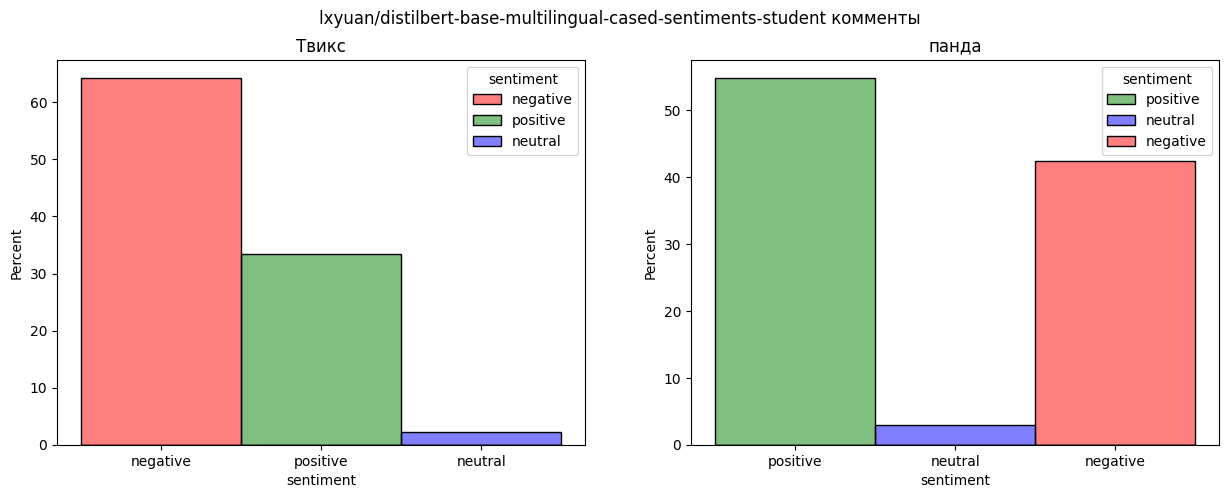

In [ ]:
plt.figure(figsize=(15,5))

plt.subplot(1,2,1)
sns.histplot(data=distilbert_com_twix, x='sentiment', stat='percent', hue='sentiment', palette=['red', 'green', 'blue'])
plt.title('Твикс')

plt.subplot(1, 2, 2)
sns.histplot(data=distilbert_com_panda, x='sentiment', stat='percent', hue='sentiment', palette=['green', 'blue', 'red'])
plt.title('панда')

plt.suptitle('lxyuan/distilbert-base-multilingual-cased-sentiments-student комменты')

plt.show()

#DeepPavlov

In [ ]:
pip install numpy==1.24.1

  Using cached numpy-1.24.1-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (17.3 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.23.5
    Uninstalling numpy-1.23.5:
      Successfully uninstalled numpy-1.23.5
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
deeppavlov 1.5.0 requires numpy<1.24, but you have numpy 1.24.1 which is incompatible.


In [ ]:
pip install scikit-learn==1.2.2

  Using cached scikit_learn-1.2.2-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (9.6 MB)
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.0.2
    Uninstalling scikit-learn-1.0.2:
      Successfully uninstalled scikit-learn-1.0.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
deeppavlov 1.5.0 requires numpy<1.24, but you have numpy 1.24.1 which is incompatible.
deeppavlov 1.5.0 requires scikit-learn<1.1.0,>=0.24, but you have scikit-learn 1.2.2 which is incompatible.


In [ ]:
!pip install -q deeppavlov

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 489.4/489.4 kB 8.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.8/55.8 kB 7.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.1/17.1 MB 63.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 81.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 222.4/222.4 kB 27.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.5/26.5 MB 60.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.5/78.5 kB 10.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.4/57.4 kB 7.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 34.4/34.4 MB 10.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.3/64.3 kB 2.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.3/58.3 kB 6.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This 

In [ ]:
import numpy
numpy.version.version

'1.24.1'

In [ ]:
!python -m deeppavlov install rusentiment_bert

Ignoring transformers: markers 'python_version < "3.8"' don't match your environment
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 27.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 34.9 MB/s eta 0:00:00
  Attempting uninstall: tokenizers
    Found existing installation: tokenizers 0.15.2
    Uninstalling tokenizers-0.15.2:
      Successfully uninstalled tokenizers-0.15.2
  Attempting uninstall: transformers
    Found existing installation: transformers 4.37.2
    Uninstalling transformers-4.37.2:
      Successfully uninstalled transformers-4.37.2


In [ ]:
from deeppavlov import build_model

model = build_model('rusentiment_bert', download=True, install=True)

2024-02-24 17:50:35.549 INFO in 'deeppavlov.core.data.utils'['utils'] at line 95: Downloading from http://files.deeppavlov.ai/v1/classifiers/rusentiment_bert/rusentiment_bert_torch.tar.gz to /root/.deeppavlov/models/classifiers/rusentiment_bert_torch.tar.gz
INFO:deeppavlov.core.data.utils:Downloading from http://files.deeppavlov.ai/v1/classifiers/rusentiment_bert/rusentiment_bert_torch.tar.gz to /root/.deeppavlov/models/classifiers/rusentiment_bert_torch.tar.gz
100%|██████████| 1.34G/1.34G [00:25<00:00, 53.7MB/s]
2024-02-24 17:51:00.836 INFO in 'deeppavlov.core.data.utils'['utils'] at line 276: Extracting /root/.deeppavlov/models/classifiers/rusentiment_bert_torch.tar.gz archive into /root/.deeppavlov/models/classifiers/rusentiment_bert_torch
INFO:deeppavlov.core.data.utils:Extracting /root/.deeppavlov/models/classifiers/rusentiment_bert_torch.tar.gz archive into /root/.deeppavlov/models/classifiers/rusentiment_bert_torch
/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_t

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/996k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.96M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]

Some weights of the model checkpoint at bert-base-multilingual-cased were not used when initializing BertForSequenceClassification: ['cls.seq_relationship.weight', 'cls.seq_relationship.bias', 'cls.predictions.bias', 'cls.predictions.transform.LayerNorm.weight', 'cls.predictions.transform.LayerNorm.bias', 'cls.predictions.transform.dense.weight', 'cls.predictions.transform.dense.bias']
- This IS expected if you are initializing BertForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-multilingual

In [ ]:
rusentiment_res = model(post)
rusentiment_res

['positive',
 'neutral',
 'neutral',
 'neutral',
 'neutral',
 'neutral',
 'neutral',
 'neutral',
 'neutral',
 'neutral',
 'neutral',
 'neutral',
 'neutral',
 'neutral',
 'neutral',
 'neutral',
 'neutral',
 'neutral',
 'neutral',
 'neutral',
 'neutral',
 'negative',
 'neutral',
 'neutral',
 'neutral',
 'neutral',
 'neutral',
 'neutral',
 'neutral',
 'negative',
 'negative',
 'neutral',
 'neutral',
 'neutral',
 'neutral',
 'neutral',
 'negative',
 'neutral',
 'neutral',
 'negative',
 'negative',
 'neutral',
 'neutral',
 'neutral',
 'neutral',
 'neutral',
 'neutral',
 'neutral',
 'neutral',
 'neutral',
 'neutral',
 'neutral',
 'neutral',
 'neutral',
 'neutral',
 'neutral',
 'neutral',
 'neutral',
 'neutral',
 'neutral',
 'neutral',
 'neutral',
 'neutral',
 'neutral',
 'neutral',
 'neutral',
 'neutral',
 'neutral',
 'neutral',
 'neutral',
 'neutral',
 'negative',
 'skip',
 'neutral',
 'neutral',
 'negative',
 'negative',
 'neutral',
 'neutral',
 'neutral',
 'neutral',
 'neutral',
 'neutral

In [ ]:
rusentiment_bert = data.assign(sentiment=rusentiment_res)
rusentiment_bert.drop(rusentiment_bert[rusentiment_bert['sentiment'] == 'skip'].index, inplace = True)
rusentiment_bert.head()

,text,date,sentiment
0,"Видео дня: толстенького той-терьера Арчи вернули хозяину. Пса искали 10 дней. Питомец оказался без хозяина в электричке и его высадили. К счастью — Арчи повезло больше, чем коту Твиксу",1706272976,positive
1,"РЖД внесут изменения в документы по перевозке животных в поездах, проводникам запретят их высаживать Поводом стал случай, когда проводница РЖД посчитала бродившего по вагону кота бездомным и выкинула его на улицу. Кота Твикса искали около недели, сегодня его нашли мертвым.",1705748566,neutral
2,"‍ Против проводницы, выбросившей кота Твикса из поезда в Кирове, завели уголовное дело Справедливо?",1706124333,neutral
3,"В РЖД запретят высаживать животных из поездов дальнего следования после трагедии с котом Твиксом. Во время поездки кот убежал из переноски и проводница выбросила его из поезда, который направлялся в Санкт-Петербург. Позже его нашли мертвым у железнодорожного переезда. В компании уже готовят изменения в нормативные документы. Теперь в подобных ситуациях животных будут передавать работникам на остановочных пунктах, а впоследствии вызывать представителей зоозащитных организаций.",1705747623,neutral
4,"166 тысяч россиян подписали петицию с требованием уволить проводницу, выкинувшую из поезда кота Твикса, что привело к его гибели.",1705773256,neutral


In [ ]:
panda_sentiment = model(panda['text'].tolist())
rusentiment_panda = panda.assign(sentiment=panda_sentiment)
rusentiment_panda.drop(rusentiment_panda[rusentiment_panda['sentiment'] == 'skip'].index, inplace = True)
rusentiment_panda.drop(rusentiment_panda[rusentiment_panda['sentiment'] == 'speech'].index, inplace = True)
rusentiment_panda.head()

,text,sentiment
0,В Московском зоопарке родился первый в истории России детеныш большой панды,neutral
1,"Детеныш панды, родившаяся в Москве, открыла глаза на 42-й день жизни, видео с ней публикует гендиректор столичного зоопарка. Маленькая панда уже реагирует на свет, но нормально видеть начнет только к концу октября.",neutral
2,"Детёныш больших панд Жуи и Диндин из Московского зоопарка впервые в жизни прошёл медосмотр в корзинке. До этого здоровье пандочки всегда проверяли в специальном инкубаторе. Малышка весит почти три килограмма. Каких-либо проблем со здоровьем у крохи не обнаружено. После осмотра панду сразу же вернули к любимой маме. Специалисты говорят, что в первое время очень важно надолго их не разлучать.",neutral
3,"Отвлекитесь от политических новостей и посмотрите, как в Московском зоопарке полный чек-ап проходит панда Жуи",neutral
4,Минутка доброты: у детеныша панды в Московском зоопарке прорезались первые зубки,neutral


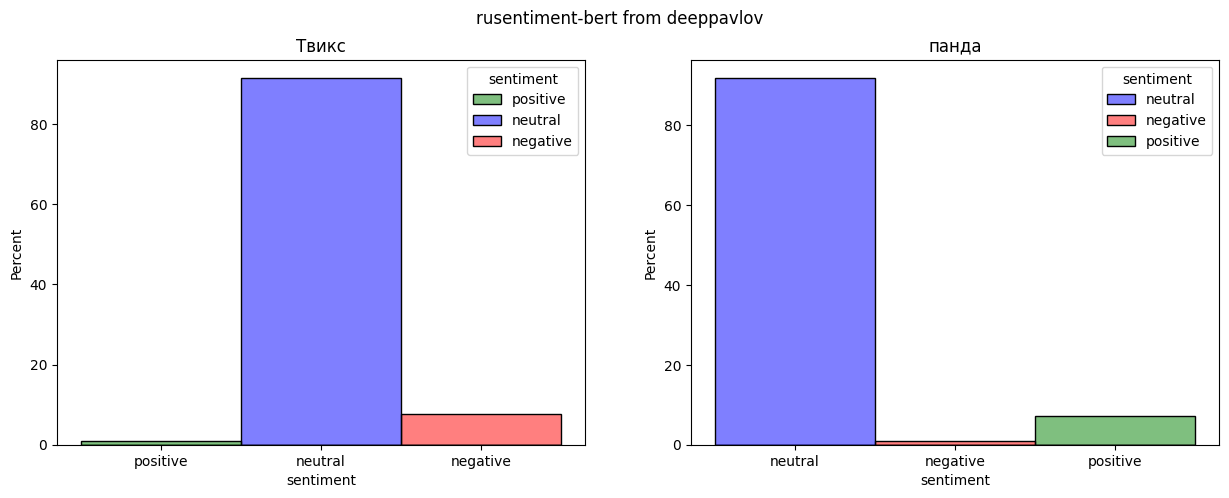

In [ ]:
plt.figure(figsize=(15,5))

plt.subplot(1,2,1)
sns.histplot(data=rusentiment_bert, x='sentiment', stat='percent', hue='sentiment', palette=['green', 'blue', 'red'])
plt.title('Твикс')

plt.subplot(1, 2, 2)
sns.histplot(data=rusentiment_panda, x='sentiment', stat='percent', hue='sentiment', palette=['blue', 'red', 'green'])
plt.title('панда')

plt.suptitle('rusentiment-bert from deeppavlov')

plt.show()

In [ ]:
rusentiment_bert[rusentiment_bert['sentiment'] == 'negative']

,text,date,sentiment
21,"Против проводницы, выбросившей кота Твикса из поезда в Кирове, завели уголовное дело — источник РИА Новости. Справедливо? ‍ – да! – ну это уже перебор... НЕ МОРГЕНШТЕРН",1706126213,negative
29,"Говорят, за мёртвого кота Твикса собрано за один день подписей в 5 раз больше, чем за почти месяц за кандидата в президенты Надеждина. Бедный Твикс! Бедный Надеждин! Сергей Марков",1705819741,negative
30,"Знаете, почему история кота Твикса так всколыхнула всех? Потому что это – разрешенный протест. Кот Твикс – это стихийный общественный протест в единственно разрешенном формате. Это как раз негатив против утраты человечности. Если хотите, это тот реальный народный негатив, который безуспешно пытались спровоцировать про голую вечеринку. Это - то самое разрешенное действие, которое можно сделать без организации начальства показухи через идущие строем трудовые коллективы. Екатерина Винокурова",1705839121,negative
36,"Кот Твикс стал огромной историей, потому что этот протест против проводницы и РЖД в защиту мёртвого кота, – просто сублимация протестных настроений. Они остались, но в условиях СВО люди опасаются их высказать. И то, что они говорят про проводницу и РЖД, они на самом деле хотели бы сказать про власть. Но боятся. Сергей Марков",1705955555,negative
39,"Выступлю со всеми не в ногу. Про проводницу. Для меня, как котовладелицы, гибель кота Твикса — это шок и трагедия… Но давайте так. Каждый человек может сделать глупость, которая приведет к трагическим последствиям. Важно — не делать таких глупостей больше. Я не видела ни единой ситуации, когда жертва травли становилась бы в итоге лучше. Какова ваша цель? Чтобы проводница (а у нее есть еще и семья) озлобилась? Чтобы трагедии и несчастья умножились? Или чтобы таких трагедий было меньше? Нельзя никого заставить силой любить животных. Более того, я не считаю, что публичные расправы и возмездие приносят счастье и тем, кто их наблюдает. Я согласна, что в РЖД этой даме работать больше не стоит, но призывать кого-то убивать, сажать на гигантские сроки я не буду, уж простите. Екатерина Винокурова",1706009282,negative
40,"Депутат Госдумы, первый зампред фракции «Справедливая Россия» Дмитрий Гусев о ситуации с котором Твиксом специально для BRIEF: Крайней, конечно, оказалась проводница. Хотела как лучше — получилось так, как получилось. Но мы сейчас, требуя наказания для нее, ничего не добьемся. Надо успокоиться. Она уже триста раз себя прокляла и прокляла свои действия. Я думаю, что она уже не знает, что делать, и я уверен, что ей за свой поступок стыдно. Это — самое главное для нее наказание, как она с этим потом будет жить. А нам сейчас надо не уподобляться этой проводнице, не применять к ней карательные действия, тем более, что правоохранительные органы уже провели проверку и не усмотрели в ее действиях уголовного состава.",1706009582,negative
71,"Адвокат владельца кота Твикса Сергей Егоров подтвердил возбуждение дела после гибели животного, выкинутого из поезда в Кирове на мороз. Его завели 24 января по ч. 1 ст. 245 УК (жестокое обращение с животными). «Вчера [хозяина кота] Эдгара [Гайфуллина] допросили в качестве потерпевшего, признали потерпевшим», — рассказал адвокат. При этом защита считает, что дело должно быть также возбуждено по статье об умышленном уничтожении или повреждении имущества (статья 167 УК).",1706191681,negative
75,"Многие накинулись с критикой на проводницу, высадившую кота на мороз. Да, с человеческой точки зрения она поступила неправильно, хотя и действовала по регламенту. К тому же раскаялась и принесла извинения. И демонизировать проводницу, как минимум, странно. А вот обратить внимание на безответственность пассажира, который перевозил Твикса, точно стоит. На Эдгаре Гайфуллине лежит уж точно не меньшая вина. Но судя по его комментариям, мужик хочет выжать максимум из этой истории, поймать хайп на гибели животного. ""Это конечно печальная история. Но с другой стороны, проводнице сложно что-либо предъявить. В наше время эпидемий, вирусов и 

In [ ]:
rusentiment_panda[rusentiment_panda['sentiment'] == 'negative']

,text,sentiment
11,"Российский бамбук не понравился большим пандам Жуи и Диньдинь из Московского зоопарка Бамбук изначально привозили из Китая, но из-за пандемии начали возить из Адлера. Панды не очень оценили его, видимо, он оказался суховатым и недостаточно влажным. Сейчас бамбук возят из Голландии.",negative
103,"В московском зоопарке у пары больших панд Жуи и Диндин родился детёныш. Это большая редкость и первый случай в истории России. Малыш весит всего 150 гр, его пол пока неизвестен. Когда уже есть своя лужайка в Москве Подписаться на СМИ",negative
